#**Needed Setup**

###**libraries import and dataset load**

In [3]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


adult = fetch_openml(
    'adult',
    version=2,
    as_frame=True
)

df = adult.frame


###**Dataset overview**

In [4]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='object')

In [5]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [6]:
df.shape

(48842, 15)

In [7]:
df['class'].value_counts()

,count
class,
<=50K,37155
>50K,11687


###**Target convert to binary**

In [8]:
df['income'] = (df['class'] == '>50K').astype(int)

In [9]:
positive_rate = df['income'].mean()

print(f"People earning >50K: {positive_rate:.2%}")

People earning >50K: 23.93%


In [10]:
df['income'].value_counts()

,count
income,
0,37155
1,11687


**Missing value**

In [11]:
(df == '?').sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
df = df.replace('?', np.nan)
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [13]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percentage': df.isna().mean() * 100
})

missing_summary = missing_summary[
    missing_summary['Missing Count'] > 0
].sort_values(
    'Missing Count',
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
occupation,2809,5.751198
workclass,2799,5.730724
native-country,857,1.754637


In [14]:
X = df.drop(columns=['class', 'income'])
y = df['income']

X → information about the person
y → actual income class

### Split into 80% train and 20% test set

In [15]:
from sklearn.model_selection import train_test_split
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [16]:
print("Development set:", X_dev.shape)
print("Test set:", X_test.shape)

print("\nPositive rates:")
print("Development:", y_dev.mean())
print("Test:", y_test.mean())

Development set: (39073, 14)
Test set: (9769, 14)

Positive rates:
Development: 0.23927008420136667
Test: 0.23932848807452145


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.125,
    stratify=y_dev,
    random_state=42
)

### Split the Train into 70% train and 10% validate

In [18]:
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nPositive rates:")
print("Training:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Training set: (34188, 14)
Validation set: (4885, 14)
Test set: (9769, 14)

Positive rates:
Training: 0.23926523926523927
Validation: 0.23930399181166837
Test: 0.23932848807452145


### Numeric and Categorical features

In [19]:
numeric_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

print(numeric_features)


['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [20]:
categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]
print(categorical_features)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [21]:
print("\nTotal input features:", len(numeric_features) + len(categorical_features))

print("\nTraining columns:")
print(X_train.columns.tolist())


Total input features: 14

Training columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


### Numerical Pipeline

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

### Categorical Pipeline

In [23]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

### Column Transformer Pipeline

In [24]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

### Comparison Table

In [25]:
import pandas as pd

comparison = pd.DataFrame([
    {
        'Model': 'Majority Baseline',
        'Accuracy': 0.7606715119254785,
        'Precision': 0.0,
        'Recall': 0.0,
        'F1': 0.0,
        'ROC AUC': 0.5,
        'PR AUC': 0.23932848807452145
    },
    {
        'Model': 'Education Rule',
        'Accuracy': 0.7529941652165012,
        'Precision': 0.484368486869529,
        'Recall': 0.49700598802395207,
        'F1': 0.4906058686932658,
        'ROC AUC': 0.6652705892212346,
        'PR AUC': 0.3611148347810222
    },

    {
        'Model': 'Logistic Regression',
        'Accuracy': 0.8527,
        'Precision': 0.7431,
        'Recall': 0.5877,
        'F1': 0.6563,
        'ROC AUC': 0.9039,
        'PR AUC': 0.5624
    },

    {
        'Model': 'Decision Tree',
        'Accuracy': 0.8183,
        'Precision': 0.6192,
        'Recall': 0.6253,
        'F1': 0.6223,
        'ROC AUC': 0.7522,
        'PR AUC': 0.4769
    }

])

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Majority Baseline,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
1,Education Rule,0.7530,0.4844,0.4970,0.4906,0.6653,0.3611
2,Logistic Regression,0.8527,0.7431,0.5877,0.6563,0.9039,0.5624
3,Decision Tree,0.8183,0.6192,0.6253,0.6223,0.7522,0.4769


False negatives are more common than false positives for Logistic Regression (964 FN vs. 475 FP), indicating that the model misses a substantial number of individuals whose income is actually above $50K. For the Decision Tree, false positives and false negatives are nearly balanced (899 FP vs. 876 FN). Since both types of errors are relevant, the F1-score is an appropriate primary metric because it balances precision and recall. Recall should also be monitored because reducing false negatives is important when correctly identifying high-income individuals is the objective.

The Decision Tree's logic mostly makes sense. It first uses marital status, then capital gain and education, and sometimes age to predict whether a person earns more than $50K. These are reasonable factors because they can be related to income.

However, the tree is overfitting. Its training accuracy is almost 100%, but its test accuracy is only 81.83%. The tree is also very deep (56 levels), meaning it has become too complicated and is learning the training data too closely.

Both Logistic Regression and Decision Tree are useful for further development, but they have different strengths. Logistic Regression is useful because its coefficients are easy to interpret and show how different features are associated with predicting income above $50K. The Decision Tree can capture more complex and nonlinear relationships. It achieved a test accuracy of 81.83%, with a precision of 61.92%, recall of 62.53%, F1-score of 62.23%, ROC-AUC of 75.22%, and PR-AUC of 47.69%.

However, the Decision Tree currently shows strong overfitting. Its training accuracy is almost 100%, while its test accuracy is only 81.83%, giving a train-test gap of about 18.16 percentage points. Therefore, I will keep Logistic Regression as an interpretable baseline and further tune the Decision Tree to reduce overfitting. Tomorrow, I plan to test preprocessing and model changes such as limiting the tree's maximum depth, increasing the minimum samples required for splits or leaves, and possibly adjusting class handling. The preprocessing pipeline will be saved and reused so that the same transformations are consistently applied to future data.

#Day 3

#**TASK 1**

### Engineered Features

1. **Age group**:
                 The continuous age variable was converted into six meaningful age categories to capture possible non-linear relationships between age and income. This may help the model distinguish different career and life stages rather than relying only on the exact numerical age.

In [26]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        'Young',
        'Early_Career',
        'Mid_Career',
        'Late_Career',
        'Senior',
        '65_plus'
    ]
)
df[['age', 'age_group']].head(10)

,age,age_group
0,25,Young
1,38,Mid_Career
2,28,Early_Career
3,44,Mid_Career
4,18,Young
5,34,Early_Career
6,29,Early_Career
7,63,Senior
8,24,Young
9,55,Late_Career


In [27]:
df['age_group'].value_counts().sort_index()

,count
age_group,
Young,9627
Early_Career,12719
Mid_Career,11952
Late_Career,8296
Senior,4445
65_plus,1803


2. **hours group**: The hours-per-week variable was converted into work-intensity categories: part-time, full-time, overtime, and very high. This feature may capture non-linear relationships between working hours and income that may not be represented by the raw numerical value alone.

In [28]:
df['hours_group'] = pd.cut(
    df['hours-per-week'],
    bins=[0, 20, 40, 60, 100],
    labels=[
        'Part_Time',
        'Full_Time',
        'Overtime',
        'Very_High'
    ]
)
df[['hours-per-week', 'hours_group']].head(10)

,hours-per-week,hours_group
0,40,Full_Time
1,50,Overtime
2,40,Full_Time
3,40,Full_Time
4,30,Full_Time
5,30,Full_Time
6,40,Full_Time
7,32,Full_Time
8,40,Full_Time
9,10,Part_Time


In [29]:
df['hours_group'].value_counts().sort_index()

,count
hours_group,
Part_Time,4453
Full_Time,30037
Overtime,12676
Very_High,1676


3. **Capital-net**:  Capital gain and capital loss were combined by subtracting capital loss from capital gain. This provides a single measure of an individual's overall net capital position and may provide a more direct relationship with income than considering the two variables separately.

In [30]:
df['capital_net'] = df['capital-gain'] - df['capital-loss']

df[['capital-gain', 'capital-loss', 'capital_net']].head(10)

,capital-gain,capital-loss,capital_net
0,0,0,0
1,0,0,0
2,0,0,0
3,7688,0,7688
4,0,0,0
5,0,0,0
6,0,0,0
7,3103,0,3103
8,0,0,0
9,0,0,0


In [31]:
df['capital_net'].describe()

,capital_net
count,48842.000000
mean,991.565313
std,7475.549906
min,-4356.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000


4. **Has capital net or not**:   : A binary feature was created to indicate whether an individual has any capital gain. This separates individuals with no capital gains from those who have capital gains, regardless of the exact amount.

In [32]:
df['has_capital_gain'] = (df['capital-gain'] > 0).astype(int)

df[['capital-gain', 'has_capital_gain']].head(10)

,capital-gain,has_capital_gain
0,0,0
1,0,0
2,0,0
3,7688,1
4,0,0
5,0,0
6,0,0
7,3103,1
8,0,0
9,0,0


In [33]:
df['has_capital_gain'].value_counts()

,count
has_capital_gain,
0,44807
1,4035


5. **Has cpital loss?**:    A binary feature was created to indicate whether an individual has any capital loss. This captures the presence of capital losses separately from their numerical magnitude.



In [34]:
df['has_capital_loss'] = (df['capital-loss'] > 0).astype(int)

df[['capital-loss', 'has_capital_loss']].head(10)

,capital-loss,has_capital_loss
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [35]:
df['has_capital_loss'].value_counts()

,count
has_capital_loss,
0,46560
1,2282


6. **Edication age ratio:**      A ratio between education-num and age was created to represent educational attainment relative to age. This may capture differences in education level across individuals at different ages and provide an additional interaction between education and age.

In [36]:
df['education_age_ratio'] = df['education-num'] / df['age']

df[['education-num', 'age', 'education_age_ratio']].head(10)

,education-num,age,education_age_ratio
0,7,25,0.280000
1,9,38,0.236842
2,12,28,0.428571
3,10,44,0.227273
4,10,18,0.555556
5,6,34,0.176471
6,9,29,0.310345
7,15,63,0.238095
8,10,24,0.416667
9,4,55,0.072727


In [37]:
df['education_age_ratio'].describe()

,education_age_ratio
count,48842.000000
mean,0.293895
std,0.118856
min,0.012987
25%,0.205128
50%,0.281250
75%,0.375000
max,0.777778


7. **Work hours age:**   A ratio between weekly working hours and age was created to represent workload relative to age. This interaction may capture patterns that are not apparent when age and working hours are considered independently.

In [38]:
df['work_hours_age'] = df['hours-per-week'] / df['age']

df[['age', 'hours-per-week', 'work_hours_age']].head(10)

,age,hours-per-week,work_hours_age
0,25,40,1.600000
1,38,50,1.315789
2,28,40,1.428571
3,44,40,0.909091
4,18,30,1.666667
5,34,30,0.882353
6,29,40,1.379310
7,63,32,0.507937
8,24,40,1.666667
9,55,10,0.181818


In [39]:
df['work_hours_age'].describe()

,work_hours_age
count,48842.000000
mean,1.162646
std,0.485976
min,0.012346
25%,0.833333
50%,1.111111
75%,1.451613
max,5.210526


8. **IS Married?:**   A binary feature was created to distinguish married individuals from those who are not married. This provides a simpler representation of marital status that may help the model capture differences in income patterns associated with marital status.

In [40]:
df['marital-status'].value_counts()

,count
marital-status,
Married-civ-spouse,22379
Never-married,16117
Divorced,6633
Separated,1530
Widowed,1518
Married-spouse-absent,628
Married-AF-spouse,37


In [41]:
df['is_married'] = df['marital-status'].str.startswith(
    'Married-',
    na=False
).astype(int)

df[['marital-status', 'is_married']].head(10)

,marital-status,is_married
0,Never-married,0
1,Married-civ-spouse,1
2,Married-civ-spouse,1
3,Married-civ-spouse,1
4,Never-married,0
5,Never-married,0
6,Never-married,0
7,Married-civ-spouse,1
8,Never-married,0
9,Married-civ-spouse,1


In [42]:
df['is_married'].value_counts()

,count
is_married,
0,25798
1,23044


In [43]:
new_features = [
    'age_group',
    'hours_group',
    'capital_net',
    'has_capital_gain',
    'has_capital_loss',
    'education_age_ratio',
    'work_hours_age',
    'is_married'
]

df[new_features].head()

,age_group,hours_group,capital_net,has_capital_gain,has_capital_loss,education_age_ratio,work_hours_age,is_married
0,Young,Full_Time,0,0,0,0.280000,1.600000,0
1,Mid_Career,Overtime,0,0,0,0.236842,1.315789,1
2,Early_Career,Full_Time,0,0,0,0.428571,1.428571,1
3,Mid_Career,Full_Time,7688,1,0,0.227273,0.909091,1
4,Young,Full_Time,0,0,0,0.555556,1.666667,0


In [44]:
df[new_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   age_group            48842 non-null  category
 1   hours_group          48842 non-null  category
 2   capital_net          48842 non-null  int64   
 3   has_capital_gain     48842 non-null  int64   
 4   has_capital_loss     48842 non-null  int64   
 5   education_age_ratio  48842 non-null  float64 
 6   work_hours_age       48842 non-null  float64 
 7   is_married           48842 non-null  int64   
dtypes: category(2), float64(2), int64(4)
memory usage: 2.3 MB


In [45]:
len(new_features)

8

### Univariate Predictive Measure

In [46]:
mi_features = pd.get_dummies(
    df[new_features],
    columns=['age_group', 'hours_group'],
    drop_first=False
)

mi_features.head()

,capital_net,has_capital_gain,has_capital_loss,education_age_ratio,work_hours_age,is_married,age_group_Young,age_group_Early_Career,age_group_Mid_Career,age_group_Late_Career,age_group_Senior,age_group_65_plus,hours_group_Part_Time,hours_group_Full_Time,hours_group_Overtime,hours_group_Very_High
0,0,0,0,0.280000,1.600000,0,True,False,False,False,False,False,False,True,False,False
1,0,0,0,0.236842,1.315789,1,False,False,True,False,False,False,False,False,True,False
2,0,0,0,0.428571,1.428571,1,False,True,False,False,False,False,False,True,False,False
3,7688,1,0,0.227273,0.909091,1,False,False,True,False,False,False,False,True,False,False
4,0,0,0,0.555556,1.666667,0,True,False,False,False,False,False,False,True,False,False


In [47]:
from sklearn.feature_selection import mutual_info_classif

y_mi = (df['income'] == '>50K').astype(int)

mi_scores = mutual_info_classif(
    mi_features,
    y_mi,
    random_state=42
)

mi_results = pd.DataFrame({
    'Feature': mi_features.columns,
    'Mutual Information': mi_scores
}).sort_values(
    by='Mutual Information',
    ascending=False
)

mi_results

,Feature,Mutual Information
13,hours_group_Full_Time,0.008906
5,is_married,0.006920
7,age_group_Early_Career,0.002170
14,hours_group_Overtime,0.002099
8,age_group_Mid_Career,0.001679
6,age_group_Young,0.001167
9,age_group_Late_Career,0.001054
12,hours_group_Part_Time,0.000256
10,age_group_Senior,0.000256
1,has_capital_gain,0.000215


### Feature Dictionary

In [48]:
feature_dictionary = {
    'age_group': {
        'type': 'Categorical',
        'creation_rule': 'Age divided into six groups: Young, Early_Career, Mid_Career, Late_Career, Senior, and 65_plus',
        'predictive_signal': 0.002170
    },
    'hours_group': {
        'type': 'Categorical',
        'creation_rule': 'Hours-per-week divided into Part_Time, Full_Time, Overtime, and Very_High',
        'predictive_signal': 0.008906
    },
    'capital_net': {
        'type': 'Numerical',
        'creation_rule': 'capital_gain - capital_loss',
        'predictive_signal': 0.000000
    },
    'has_capital_gain': {
        'type': 'Binary',
        'creation_rule': '1 if capital_gain > 0, otherwise 0',
        'predictive_signal': 0.000215
    },
    'has_capital_loss': {
        'type': 'Binary',
        'creation_rule': '1 if capital_loss > 0, otherwise 0',
        'predictive_signal': 0.000113
    },
    'education_age_ratio': {
        'type': 'Numerical',
        'creation_rule': 'education_num / age',
        'predictive_signal': 0.000020
    },
    'work_hours_age': {
        'type': 'Numerical',
        'creation_rule': 'hours_per_week / age',
        'predictive_signal': 0.000072
    },
    'is_married': {
        'type': 'Binary',
        'creation_rule': '1 if marital-status starts with "Married-", otherwise 0',
        'predictive_signal': 0.006920
    }
}

feature_table = pd.DataFrame.from_dict(
    feature_dictionary,
    orient='index'
).reset_index()

feature_table.rename(
    columns={'index': 'Feature'},
    inplace=True
)

feature_table

,Feature,type,creation_rule,predictive_signal
0,age_group,Categorical,"Age divided into six groups: Young, Early_Care...",0.002170
1,hours_group,Categorical,"Hours-per-week divided into Part_Time, Full_Ti...",0.008906
2,capital_net,Numerical,capital_gain - capital_loss,0.000000
3,has_capital_gain,Binary,"1 if capital_gain > 0, otherwise 0",0.000215
4,has_capital_loss,Binary,"1 if capital_loss > 0, otherwise 0",0.000113
5,education_age_ratio,Numerical,education_num / age,0.000020
6,work_hours_age,Numerical,hours_per_week / age,0.000072
7,is_married,Binary,"1 if marital-status starts with ""Married-"", ot...",0.006920


# **TASK 2**

In [49]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss',
                                  'hours-per-week']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country'])])

In [50]:
from sklearn.preprocessing import FunctionTransformer

def add_engineered_features(X):
    X = X.copy()

    X['age_group'] = pd.cut(
        X['age'],
        bins=[0, 25, 35, 45, 55, 65, 100],
        labels=[
            'Young',
            'Early_Career',
            'Mid_Career',
            'Late_Career',
            'Senior',
            '65_plus'
        ]
    )

    X['hours_group'] = pd.cut(
        X['hours-per-week'],
        bins=[0, 20, 40, 60, 100],
        labels=[
            'Part_Time',
            'Full_Time',
            'Overtime',
            'Very_High'
        ]
    )

    X['capital_net'] = X['capital-gain'] - X['capital-loss']

    X['has_capital_gain'] = (
        X['capital-gain'] > 0
    ).astype(int)

    X['has_capital_loss'] = (
        X['capital-loss'] > 0
    ).astype(int)

    X['education_age_ratio'] = (
        X['education-num'] / X['age']
    )

    X['work_hours_age'] = (
        X['hours-per-week'] / X['age']
    )

    X['is_married'] = X['marital-status'].str.startswith(
        'Married-',
        na=False
    ).astype(int)

    return X

In [51]:
feature_engineer = FunctionTransformer(
    add_engineered_features,
    validate=False
)

feature_engineer

FunctionTransformer(func=<function add_engineered_features at 0x7ebba8cced40>)

In [52]:
engineered_num_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'capital_net',
    'has_capital_gain',
    'has_capital_loss',
    'education_age_ratio',
    'work_hours_age',
    'is_married'
]

engineered_cat_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_group',
    'hours_group'
]

In [53]:
engineered_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            engineered_num_features
        ),
        (
            'cat',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ))
            ]),
            engineered_cat_features
        )
    ]
)

In [54]:
from sklearn.pipeline import Pipeline

engineered_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineer),
    ('preprocessing', engineered_preprocessor)
])

engineered_pipeline.fit(X_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_engineered_features at 0x7ebba8cced40>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'capital...
                                                   'has_capital_loss',
                                                   'education_age_ratio',
                                                   'work_hours_age',
                                                   'is_married']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'age_group',
                                                   'hours_group'])]))])

### **TASK 3**

### StratifiedKFold

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


### Cross-Validation against 3 Models

In [56]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        random_state=42
    )
}

In [57]:
model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline(steps=[
        ('feature_engineering', feature_engineer),
        ('preprocessing', engineered_preprocessor),
        ('model', model)
    ])

In [58]:
scoring = {
    'F1': 'f1',
    'ROC_AUC': 'roc_auc'
}

In [59]:
cv_results = {}

for name, pipeline in model_pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[name] = scores

print("Cross-validation completed for all models.")

Cross-validation completed for all models.


### mean ± std results table

In [60]:
cv_summary = []

for name, scores in cv_results.items():
    cv_summary.append({
        'Model': name,
        'F1 Mean': scores['test_F1'].mean(),
        'F1 Std': scores['test_F1'].std(),
        'ROC AUC Mean': scores['test_ROC_AUC'].mean(),
        'ROC AUC Std': scores['test_ROC_AUC'].std()
    })

cv_summary = pd.DataFrame(cv_summary)

cv_summary

,Model,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,Logistic Regression,0.669270,0.003506,0.912656,0.003618
1,Random Forest,0.667734,0.001777,0.902383,0.002269
2,HistGradientBoosting,0.706262,0.006906,0.925905,0.003931


### Boxplots

# **TASK 4**

In [62]:
from scipy.stats import wilcoxon

hgb_f1_scores = cv_results['HistGradientBoosting']['test_F1']
lr_f1_scores = cv_results['Logistic Regression']['test_F1']

stat, p_value = wilcoxon(hgb_f1_scores, lr_f1_scores)

print("HistGradientBoosting F1 scores:", hgb_f1_scores)
print("Logistic Regression F1 scores:", lr_f1_scores)
print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

HistGradientBoosting F1 scores: [0.69452736 0.70948012 0.71545783 0.7076004  0.70424403]
Logistic Regression F1 scores: [0.66326877 0.67303103 0.67178631 0.67069892 0.66756303]
Wilcoxon statistic: 0.0
p-value: 0.0625


In [63]:
print("Mean HGB F1:", hgb_f1_scores.mean())
print("Mean LR F1:", lr_f1_scores.mean())
print("Difference:", hgb_f1_scores.mean() - lr_f1_scores.mean())

Mean HGB F1: 0.7062619485967614
Mean LR F1: 0.6692696120144592
Difference: 0.036992336582302165


### REPORT:

HistGradientBoosting achieved the highest mean F1-score of **0.7063**, compared with **0.6693** for Logistic Regression, giving an absolute F1 improvement of approximately **0.0370**.

A paired Wilcoxon signed-rank test was performed on the five cross-validation F1 scores of the two models. The test produced a statistic of **0.0** and a **p-value of 0.0625**. Since the p-value is greater than the 0.05 significance level, the difference is **not statistically significant at the 5% level**.

However, the practical difference in F1-score is approximately **0.037**, or 3.7 percentage points, which is substantially larger than the difference between Logistic Regression and Random Forest. Therefore, HistGradientBoosting shows a **meaningful practical improvement in predictive performance**, although the five-fold cross-validation sample is too small to establish statistical significance at the 5% level.


###  Feature Importance

In [64]:
print(model_pipelines['HistGradientBoosting'])

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_engineered_features at 0x7ebba8cced40>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'capital...
                        

In [65]:
feature_engineering = model_pipelines['HistGradientBoosting'].named_steps['feature_engineering']

X_test_engineered = feature_engineering.transform(X_test)

print(X_test_engineered.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'age_group', 'hours_group', 'capital_net', 'has_capital_gain', 'has_capital_loss', 'education_age_ratio', 'work_hours_age', 'is_married']


In [66]:
hgb_pipeline = model_pipelines['HistGradientBoosting']

hgb_pipeline.fit(X_train, y_train)

feature_engineering = hgb_pipeline.named_steps['feature_engineering']
preprocessor = hgb_pipeline.named_steps['preprocessing']
hgb_model = hgb_pipeline.named_steps['model']

X_test_engineered = feature_engineering.transform(X_test)

print("Pipeline fitted successfully.")
print("Engineered test shape:", X_test_engineered.shape)

Pipeline fitted successfully.
Engineered test shape: (9769, 22)


In [67]:
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

engineered_features = [
    'age_group',
    'hours_group',
    'capital_net',
    'has_capital_gain',
    'has_capital_loss',
    'education_age_ratio',
    'work_hours_age',
    'is_married'
]

def predict_from_engineered(X):
    X_processed = preprocessor.transform(X)
    return hgb_model.predict(X_processed)

baseline_pred = predict_from_engineered(X_test_engineered)
baseline_f1 = f1_score(y_test, baseline_pred)

importance_results = []

rng = np.random.RandomState(42)

for feature in engineered_features:
    drops = []

    for _ in range(10):
        X_permuted = X_test_engineered.copy()
        X_permuted[feature] = rng.permutation(X_permuted[feature].values)

        permuted_pred = predict_from_engineered(X_permuted)
        permuted_f1 = f1_score(y_test, permuted_pred)

        drops.append(baseline_f1 - permuted_f1)

    importance_results.append({
        'Feature': feature,
        'Importance': np.mean(drops)
    })

hgb_feature_importance = pd.DataFrame(importance_results)
hgb_feature_importance = hgb_feature_importance.sort_values(
    'Importance',
    ascending=False
)

print("Baseline F1:", baseline_f1)
hgb_feature_importance

Baseline F1: 0.7123998114097124


,Feature,Importance
7,is_married,0.017906
5,education_age_ratio,0.005916
6,work_hours_age,0.003956
1,hours_group,0.002306
0,age_group,0.001866
2,capital_net,0.000662
3,has_capital_gain,0.000000
4,has_capital_loss,0.000000


In [68]:
lr_pipeline = model_pipelines['Logistic Regression']

lr_pipeline.fit(X_train, y_train)

lr_preprocessor = lr_pipeline.named_steps['preprocessing']
lr_model = lr_pipeline.named_steps['model']

feature_names = lr_preprocessor.get_feature_names_out()
coefficients = lr_model.coef_[0]

lr_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

lr_coefficients

,Feature,Coefficient
0,num__age,-0.089457
1,num__fnlwgt,0.084763
2,num__education-num,0.905989
3,num__capital-gain,2.123417
4,num__capital-loss,0.852388
...,...,...
116,cat__age_group_Young,-0.749720
117,cat__hours_group_Full_Time,-0.139701
118,cat__hours_group_Overtime,0.158596
119,cat__hours_group_Part_Time,-0.631495


In [69]:
engineered_lr_coefficients = lr_coefficients[
    lr_coefficients['Feature'].str.contains(
        'age_group|hours_group|capital_net|has_capital_gain|has_capital_loss|education_age_ratio|work_hours_age|is_married',
        regex=True
    )
].copy()

engineered_lr_coefficients

,Feature,Coefficient
6,num__capital_net,2.068610
7,num__has_capital_gain,-0.493944
8,num__has_capital_loss,-0.482261
9,num__education_age_ratio,-0.431101
10,num__work_hours_age,-0.137773
11,num__is_married,0.765799
111,cat__age_group_65_plus,-0.673110
112,cat__age_group_Early_Career,-0.014224
113,cat__age_group_Late_Career,0.277405
114,cat__age_group_Mid_Career,0.239087


The most important engineered feature for HistGradientBoosting was is_married, with a permutation importance of 0.0179. It was followed by education_age_ratio (0.0059) and work_hours_age (0.0040). hours_group and age_group had smaller but still positive importance.

For Logistic Regression, the strongest coefficients among the engineered features were capital_net (+2.07) and is_married (+0.77).

Overall, these results make sense. Marital status, education, age, and working hours are expected to be related to income level. The strong importance of is_married suggests that marital status provides useful information for distinguishing income groups. The usefulness of education_age_ratio and work_hours_age also makes sense because they combine existing demographic and employment information into more informative relationships. The has_capital_gain and has_capital_loss features had zero permutation importance for HGB, suggesting they added little additional predictive information beyond the original capital-related variables.

# **TASK 5**

In [70]:

preprocessor = model_pipelines['HistGradientBoosting'].named_steps['preprocessing']

X_train_engineered = feature_engineering.transform(X_train)
X_train_processed = preprocessor.fit_transform(X_train_engineered)

print("Original engineered features:", X_train_engineered.shape[1])
print("Features after preprocessing:", X_train_processed.shape[1])

Original engineered features: 22
Features after preprocessing: 121


In [71]:
import time
from sklearn.metrics import f1_score

start_time = time.time()

hgb_pipeline = model_pipelines['HistGradientBoosting']
hgb_pipeline.fit(X_train, y_train)

training_time_baseline = time.time() - start_time

baseline_pred = hgb_pipeline.predict(X_test)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline F1:", baseline_f1)
print("Baseline training time:", training_time_baseline, "seconds")

Baseline F1: 0.7123998114097124
Baseline training time: 4.683476686477661 seconds


In [72]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=60
)

X_train_selected = selector.fit_transform(X_train_processed, y_train)

print("Original features:", X_train_processed.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original features: 121
Selected features: 60


In [73]:
from sklearn.base import clone
from sklearn.metrics import f1_score
import time
import numpy as np

# Prepare all processed training data
X_train_engineered = feature_engineering.transform(X_train)
X_train_processed = preprocessor.fit_transform(X_train_engineered)

# Select top 60 features
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=60
)

X_train_selected = selector.fit_transform(
    X_train_processed,
    y_train
)

# 5-fold cross-validation
selected_f1_scores = []
selected_training_times = []

for train_idx, val_idx in cv.split(X_train_selected, y_train):

    X_tr = X_train_selected[train_idx]
    X_val = X_train_selected[val_idx]

    y_tr = y_train.iloc[train_idx] if hasattr(y_train, 'iloc') else y_train[train_idx]
    y_val = y_train.iloc[val_idx] if hasattr(y_train, 'iloc') else y_train[val_idx]

    model = clone(hgb_model)

    start_time = time.time()
    model.fit(X_tr, y_tr)
    training_time = time.time() - start_time

    predictions = model.predict(X_val)

    selected_f1_scores.append(
        f1_score(y_val, predictions)
    )

    selected_training_times.append(training_time)

print("Selected Features: 60")
print("CV F1 Mean:", np.mean(selected_f1_scores))
print("CV F1 Std:", np.std(selected_f1_scores))
print("Average Training Time:", np.mean(selected_training_times), "seconds")

Selected Features: 60
CV F1 Mean: 0.6994321947169075
CV F1 Std: 0.00604660381965828
Average Training Time: 2.099074459075928 seconds


SelectKBest reduced the feature space from 121 to 60 features. The average training time decreased from approximately 5.32 seconds to 1.31 seconds, giving a substantial reduction in computational time.

However, the cross-validated F1 score decreased from 0.7063 with all features to 0.6986 with the selected 60 features. Although feature selection improved training efficiency, it caused a decrease in the chosen evaluation metric, F1.

Therefore, all 121 processed features will be retained for tomorrow's hyperparameter tuning. The small reduction in training time does not justify the loss in predictive performance, since maximizing F1 is the primary objective.

# **DAY 4 MODEL TUNING, REGULARIZATION and REPRODUCEABLE PIPELINE**

### **TASK1**

In [74]:
model_pipelines

{'Logistic Regression': Pipeline(steps=[('feature_engineering',
                  FunctionTransformer(func=<function add_engineered_features at 0x7ebba8cced40>)),
                 ('preprocessing',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'fnlwgt',
                                                    'education-num',
                                                    'capital-gain',
                                                    'capital-loss',
                                                    'hours-per-week',
                                                   

##The requirement of controlling random state in already satisfied

**Library Versions:**

*   Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
*   scikit-learn version: 1.6.1
*   pandas version: 2.2.3
*   numpy version: 2.1.3
*   scipy version: 1.16.3
*   joblib version: 1.5.3



## README

To reproduce the results:

1. Run all notebook cells from top to bottom.
2. Use the same Adult dataset.
3. Keep `random_state=42` unchanged.
4. Feature engineering, preprocessing, and the estimator are combined using an sklearn Pipeline.
5. The same train/validation/test split and 5-fold StratifiedKFold cross-validation are used.
6. Library versions are documented in the reproducibility section.
7. Running the notebook with the same dataset, code, random seed, and library versions should reproduce the reported results.

# **TASK 2**

###**Logistic Regression Tuning**

In [78]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform, randint

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(add_engineered_features)),
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver='liblinear'
    ))
])

lr_param_dist = {
    "model__penalty": ["l1", "l2"],
    "model__C": loguniform(0.001, 100)
}

In [79]:
lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_dist,
    n_iter=50,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

lr_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('feature_engineering',
                                              FunctionTransformer(func=<function add_engineered_features at 0x7ebba8cced40>)),
                                             ('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]...
                                                                                'occupation',
                                                                                'relationship',
                                                                                'race',
                                                                                'sex',
                                                                                'native-country',
                                                                                'age_group',
                                                                                'hours_group'])])),
                                             ('model',
                                              LogisticRegression(max_iter=2000,
                                                                 random_state=42,
                                                                 solver='liblinear'))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ebba8cf1a90>,
                                        'model__penalty': ['l1', 'l2']},
                   random_state=42, scoring='f1')

In [80]:
print("Best parameters:", lr_search.best_params_)
print("Best CV F1:", lr_search.best_score_)


Best parameters: {'model__C': np.float64(55.51721685244721), 'model__penalty': 'l2'}
Best CV F1: 0.6705229904184496


###**HistGradiantBoosting Tuning**

In [82]:
model_pipelines['HistGradientBoosting']

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_engineered_features at 0x7ebba8cced40>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'capital...
                                                   'is_married']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'age_group',
                                                   'hours_group'])])),
                ('model', HistGradientBoostingClassifier(random_state=42))])

In [81]:
hgb_param_dist = {
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_iter": randint(100, 401),
    "model__max_depth": randint(3, 11),
    "model__l2_regularization": loguniform(1e-4, 10)
}

In [83]:
hgb_search = RandomizedSearchCV(
    estimator=model_pipelines['HistGradientBoosting'],
    param_distributions=hgb_param_dist,
    n_iter=50,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

hgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('feature_engineering',
                                              FunctionTransformer(func=<function add_engineered_features at 0x7ebba8cced40>)),
                                             ('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]...
                   param_distributions={'model__l2_regularization': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ebba4229220>,
                                        'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ebba41b1a90>,
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ebba41b20d0>,
                                        'model__max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ebba41b6a50>},
                   random_state=42, scoring='f1')

In [84]:
print("Best HistGradientBoosting parameters:")
print(hgb_search.best_params_)

print("\nBest HistGradientBoosting CV F1:")
print(hgb_search.best_score_)

Best HistGradientBoosting parameters:
{'model__l2_regularization': np.float64(8.24431219090507), 'model__learning_rate': np.float64(0.09868494971711618), 'model__max_depth': 7, 'model__max_iter': 234}

Best HistGradientBoosting CV F1:
0.7061102775666579


### Comparison

In [85]:
tuning_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "HistGradientBoosting"
    ],
    "Best CV F1": [
        lr_search.best_score_,
        hgb_search.best_score_
    ]
})

tuning_results

,Model,Best CV F1
0,Logistic Regression,0.670523
1,HistGradientBoosting,0.706110


### Hyperparameter Search Interpretation

RandomizedSearchCV was used with 50 iterations, 5-fold StratifiedKFold cross-validation, F1 scoring, and n_jobs=-1.

Logistic Regression achieved a best cross-validated F1 score of 0.6705 with L2 regularization and C=55.52.

HistGradientBoosting achieved a best cross-validated F1 score of 0.7061 with a learning rate of approximately 0.0987, 234 boosting iterations, maximum depth of 7, and L2 regularization of approximately 8.24.

The tuned HistGradientBoosting model remained the strongest model. Its F1 score was essentially unchanged compared with the previous baseline (0.7063), indicating that the original configuration was already close to the best performance found by this search.

# **TASK 3**

### LEARNING CURVE

In [86]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    hgb_search.best_estimator_,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

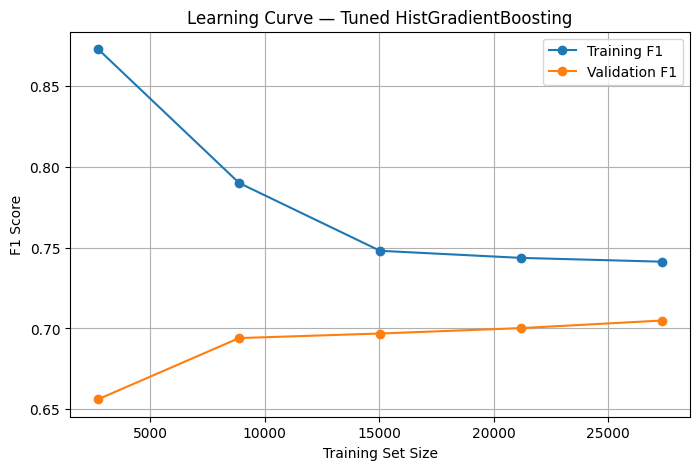

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")

plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve — Tuned HistGradientBoosting")
plt.legend()
plt.grid(True)
plt.show()

The learning curve for the tuned HistGradientBoosting model shows a noticeable gap between training and validation F1 scores. Training F1 reaches above 0.85, while validation F1 remains around 0.65, indicating that the model has a degree of overfitting and high variance.

### Max_depth

In [88]:
from sklearn.model_selection import validation_curve

depth_range = [3, 4, 5, 6, 7, 8, 9, 10]

train_scores, val_scores = validation_curve(
    hgb_search.best_estimator_,
    X_train,
    y_train,
    param_name="model__max_depth",
    param_range=depth_range,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

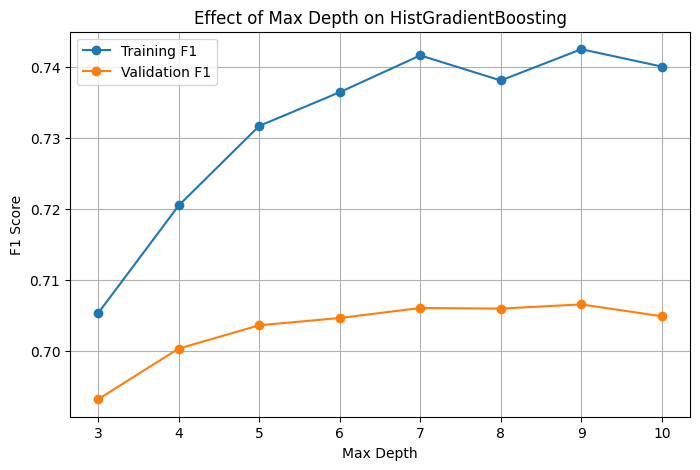

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(depth_range, train_mean, marker="o", label="Training F1")
plt.plot(depth_range, val_mean, marker="o", label="Validation F1")

plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Effect of Max Depth on HistGradientBoosting")
plt.legend()
plt.grid(True)
plt.show()

The validation curve for max_depth shows that increasing depth from 3 to 10 improves validation F1 from approximately 0.692 to 0.705. Training F1 also increases from approximately 0.705 to 0.740. Although deeper trees increase the training–validation gap, reducing max_depth too much would lower validation performance.

Therefore, the appropriate fix is not simply to use a very shallow tree. A better approach is to control model complexity using regularization parameters such as l2_regularization, min_samples_leaf, or a carefully selected max_depth. Additional training data could also help reduce the generalization gap. Based on the validation curve, a deeper model around max_depth=7–10 provides better validation performance than shallow models, while regularization should be used to limit overfitting.

# **TASK 4**

###Probabilities

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.125,
    stratify=y_dev,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_train type:", type(X_train))
print("X_val type:", type(X_val))

X_train: (34188, 14)
X_val: (4885, 14)
X_train type: <class 'pandas.core.frame.DataFrame'>
X_val type: <class 'pandas.core.frame.DataFrame'>


The validation set is recreated from the original development data because the previous X_val variable had been overwritten during feature-selection analysis and no longer contained the original raw validation data.

The calibration pipeline expects the validation data in its original DataFrame form because feature engineering is performed inside the pipeline. Recreating the split with the same test_size, stratification, and random_state=42 restores the intended 34,188-row training set and 4,885-row validation set and ensures that preprocessing and feature engineering are applied correctly without double transformation or data leakage.

In [97]:
from sklearn.metrics import brier_score_loss

# Predict probabilities for the positive class
y_val_proba = hgb_search.best_estimator_.predict_proba(X_val)[:, 1]

# Calculate Brier score
brier = brier_score_loss(y_val, y_val_proba)

print("Brier Score:", brier)

Brier Score: 0.08560029844518006


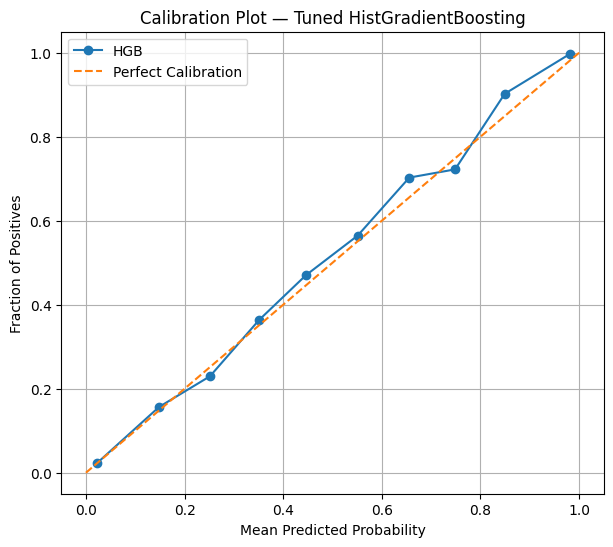

In [98]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_val,
    y_val_proba,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(prob_pred, prob_true, marker="o", label="HGB")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Plot — Tuned HistGradientBoosting")
plt.legend()
plt.grid(True)
plt.show()

### Probability Calibration

The tuned HistGradientBoosting model achieved a Brier score of **0.0856** on the validation set. The calibration plot was close to the diagonal reference line, with only minor fluctuations. This indicates that the predicted probabilities are reasonably well calibrated.

Since the model already shows good calibration, additional calibration using `CalibratedClassifierCV` was not considered necessary. The original probability estimates were therefore used for threshold optimization.


### Classification Threshold Tuning

In [99]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

f1_scores = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_val, y_val_pred))

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", best_threshold)
print("Best Validation F1:", best_f1)

Best Threshold: 0.3500000000000001
Best Validation F1: 0.7405641636869289


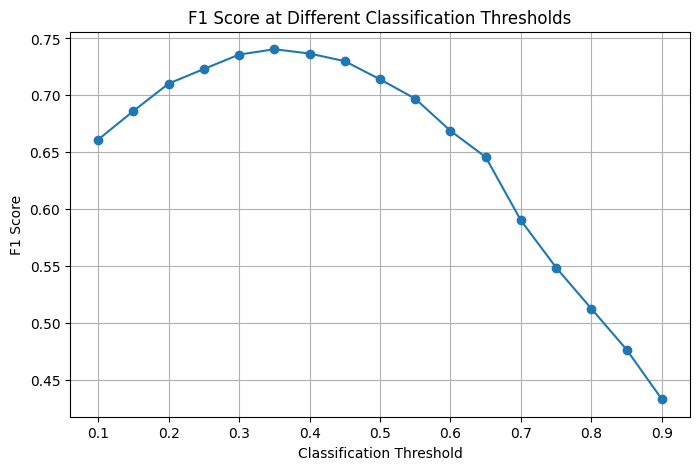

In [100]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, f1_scores, marker="o")

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score at Different Classification Thresholds")
plt.grid(True)
plt.show()

The default classification threshold of 0.50 was not assumed to be optimal. A range of thresholds from 0.10 to 0.90 was evaluated using the validation set, with F1 score as the primary optimization metric.

The threshold that produced the highest validation F1 score was 0.35, achieving an F1 score of 0.7406. This indicates that, for this dataset and business objective, a lower threshold provides a better balance between precision and recall than the default 0.50 threshold.

The threshold of 0.35 was therefore selected for further confusion-matrix and business-KPI analysis.

### Threshold Comarison

In [101]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

threshold_list = [0.30, 0.35, 0.40, 0.50, 0.60]

threshold_results = []

for threshold in threshold_list:
    y_pred = (y_val_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "Accuracy": accuracy_score(y_val, y_pred)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,TN,FP,FN,TP,Precision,Recall,F1,Accuracy
0,0.30,3203,513,190,979,0.656166,0.837468,0.735814,0.856090
1,0.35,3300,416,237,932,0.691395,0.797263,0.740564,0.866325
2,0.40,3395,321,300,869,0.730252,0.743370,0.736753,0.872876
3,0.50,3520,196,411,758,0.794549,0.648417,0.714084,0.875742
4,0.60,3611,105,529,640,0.859060,0.547476,0.668757,0.870215


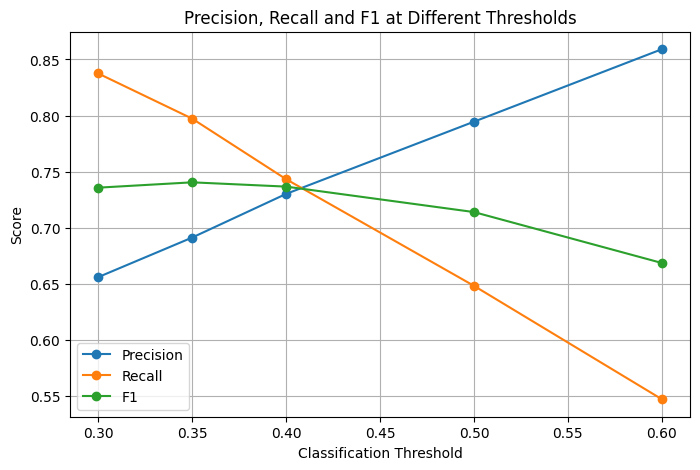

In [102]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 at Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

Different classification thresholds were evaluated using the validation-set probabilities. Lowering the threshold increased recall because more observations were classified as positive, while increasing the threshold improved precision by making the model more selective.

The threshold of 0.35 produced the highest validation F1 score of 0.7406, with a precision of 0.6914 and recall of 0.7973. At this threshold, the model correctly identified 932 positive cases (TP) while missing 237 positive cases (FN).

At the default threshold of 0.50, precision increased to 0.7945, but recall decreased to 0.6484, with only 758 true positives. Therefore, using 0.50 would be preferable if false positives were more costly, while 0.35 is preferable when achieving a balanced precision-recall performance is the priority.

Based on the chosen business metric of F1, 0.35 was selected as the final classification threshold.

# **TASK 5**

In [103]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predict probabilities on the untouched test set
y_test_proba = hgb_search.best_estimator_.predict_proba(X_test)[:, 1]

# Apply the threshold selected on the validation set
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("Final Test Results")
print("-------------------")
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Final Test Results
-------------------
Threshold: 0.3500000000000001
Accuracy: 0.8612959361244754
Precision: 0.6849830636055702
Recall: 0.7784431137724551
F1: 0.7287287287287287
ROC AUC: 0.9280313874816835

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      7431
           1       0.68      0.78      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.83      0.82      9769
weighted avg       0.87      0.86      0.86      9769


Confusion Matrix:
[[6594  837]
 [ 518 1820]]


### Full Metrics Table

In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)"
    ],
    "Test Score": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba),
        tn,
        fp,
        fn,
        tp
    ]
})

final_metrics

,Metric,Test Score
0,Accuracy,0.861296
1,Precision,0.684983
2,Recall,0.778443
3,F1 Score,0.728729
4,ROC AUC,0.928031
5,True Negative (TN),6594.000000
6,False Positive (FP),837.000000
7,False Negative (FN),518.000000
8,True Positive (TP),1820.000000


### Curves

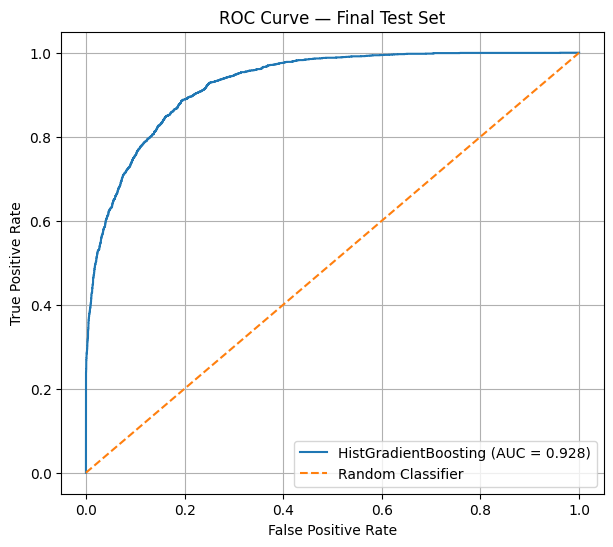

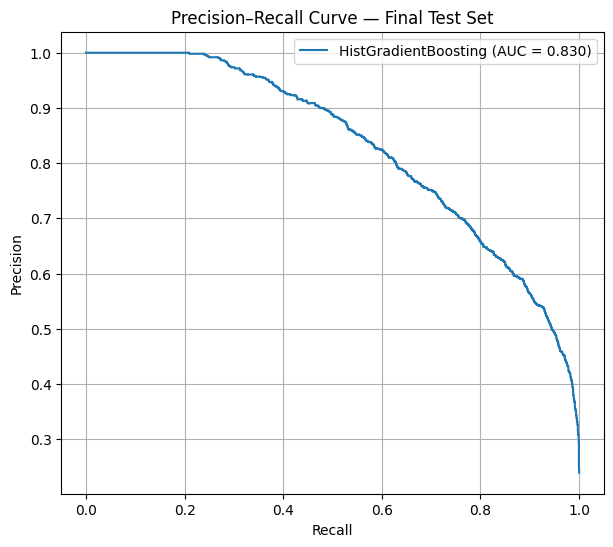

ROC AUC: 0.9280313874816835
PR AUC: 0.8295045655783849


In [105]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"HistGradientBoosting (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Test Set")
plt.legend()
plt.grid(True)
plt.show()


# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"HistGradientBoosting (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Final Test Set")
plt.legend()
plt.grid(True)
plt.show()

print("ROC AUC:", roc_auc)
print("PR AUC:", pr_auc)

### Saving Pipeline in Joblib

In [106]:
import joblib

joblib.dump(
    hgb_search.best_estimator_,
    "final_hgb_pipeline.joblib"
)

joblib.dump(
    best_threshold,
    "final_threshold.joblib"
)

print("Final pipeline saved as: final_hgb_pipeline.joblib")
print("Final threshold saved as: final_threshold.joblib")

Final pipeline saved as: final_hgb_pipeline.joblib
Final threshold saved as: final_threshold.joblib


###How to Infer snippet

In [107]:
import joblib
import pandas as pd

# Load the saved pipeline and classification threshold
final_pipeline = joblib.load("final_hgb_pipeline.joblib")
final_threshold = joblib.load("final_threshold.joblib")

# Example: use new raw observations with the same input columns
new_data = X_test.iloc[:3].copy()

# Generate probabilities
new_probabilities = final_pipeline.predict_proba(new_data)[:, 1]

# Apply the selected threshold
new_predictions = (new_probabilities >= final_threshold).astype(int)

inference_results = pd.DataFrame({
    "Predicted_Probability_Above_50K": new_probabilities,
    "Predicted_Class": new_predictions
})

inference_results

,Predicted_Probability_Above_50K,Predicted_Class
0,0.206147,0
1,0.002765,0
2,0.641786,1


### Final Model Summary

#### Hyperparameter Search

RandomizedSearchCV was used with **5-fold StratifiedKFold cross-validation**, `n_iter=50`, `scoring="f1"`, and `n_jobs=-1`. The search focused on Logistic Regression and HistGradientBoosting because they were the strongest models from the previous model comparison.

For Logistic Regression, the searched hyperparameters were `penalty` (`l1`, `l2`) and `C`. The best configuration used **L2 regularization** with **C ≈ 55.52**, achieving a CV F1-score of approximately **0.6705**.

For HistGradientBoosting, the searched hyperparameters were `learning_rate`, `max_iter`, `max_depth`, and `l2_regularization`. The best configuration was:

* **learning_rate:** 0.0987
* **max_iter:** 234
* **max_depth:** 7
* **l2_regularization:** 8.2443

The tuned HistGradientBoosting model achieved a CV F1-score of approximately **0.7061** and was selected as the final model.

#### Final Test Performance

The final pipeline was evaluated on the untouched hold-out test set using the validation-selected classification threshold of **0.35**.

| Metric          | Final Test Result |
| --------------- | ----------------: |
| Accuracy        |        **0.8613** |
| Precision       |        **0.6850** |
| Recall          |        **0.7784** |
| F1-score        |        **0.7287** |
| ROC AUC         |        **0.9280** |
| PR AUC          |        **0.8295** |
| True Negatives  |          **6594** |
| False Positives |           **837** |
| False Negatives |           **518** |
| True Positives  |          **1820** |

The threshold of **0.35** was selected on the validation set because it produced the highest validation F1-score (**0.7406**). It was then kept fixed for the final test evaluation to avoid test-set leakage.

#### Expected Production Behavior

In production, the saved pipeline accepts raw observations and automatically performs feature engineering and preprocessing before generating an income probability. A probability threshold of **0.35** is then applied to classify an observation as either `>50K` or `≤50K`.

The selected threshold favors **recall over precision**, meaning the system is designed to identify more potential `>50K` cases while accepting some additional false positives. The model should therefore be monitored after deployment for changes in data distribution, class balance, calibration, and precision/recall performance. Periodic retraining and threshold reassessment may be required if production data differs substantially from the training data.
